<img align="right" style="max-width: 200px; height: auto" src="assets/banner.png">

## Lab 06 - "End-to-End Learning & Neural Networks"

Artificial Intelligence (Spring 2026), University of St. Gallen

In this lab we will explore the building blocks of **(deep) neural networks** from the bottom up.

Objectives:

* Understand the shift from **traditional ML with handcrafted features** to **end-to-end learning**.
* Implement the simplest artificial neurons from scratch: the **McCulloch-Pitts neuron** and the **Rosenblatt perceptron**.
* See why a single neuron cannot solve the **XOR problem**, and how a **Multi-Layer Perceptron (MLP)** can.
* Get familiar with the common **activation functions** and their properties.
* Write a **vectorized forward pass** for an MLP in NumPy and view a neural network as a **nested function**.
* Get a first introduction to **PyTorch** and re-implement our MLP with `torch.nn`.

> Note: training the network (backpropagation, gradient descent) is covered in the next lecture. In this lab we only look at **forward passes** with either hand-set or random weights.

### Part 0: Setup

We will use three libraries:

* [NumPy](https://numpy.org/) for vector/matrix math.
* [Matplotlib](https://matplotlib.org/) for plotting.
* [PyTorch](https://pytorch.org/) for the neural-network part at the end.

In [1]:
!pip3 install numpy matplotlib torch -q


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

### Part 1: Traditional ML vs. End-to-End Learning

In traditional machine learning, a human expert designs **handcrafted features** (edges, histograms of gradients, SIFT, color histograms, ...) and a separate classifier is trained on top of them:

```
raw input  →  [handcrafted feature extractor]  →  features  →  [classifier]  →  y
```

The feature extractor is **fixed**; only the classifier is learned.

In **end-to-end learning**, features *and* classifier are learned jointly as one cascade of non-linear transformations:

```
raw input  →  [ layer 1 → layer 2 → ... → layer L ]  →  y
                           (all learned together)
```

This means the model learns its **own internal representation** of the input, adapted to the task.

Let's illustrate this with a tiny toy example. We generate two classes of 2D points that are **not linearly separable** in the raw input space, and build a small "handcrafted feature" by hand.

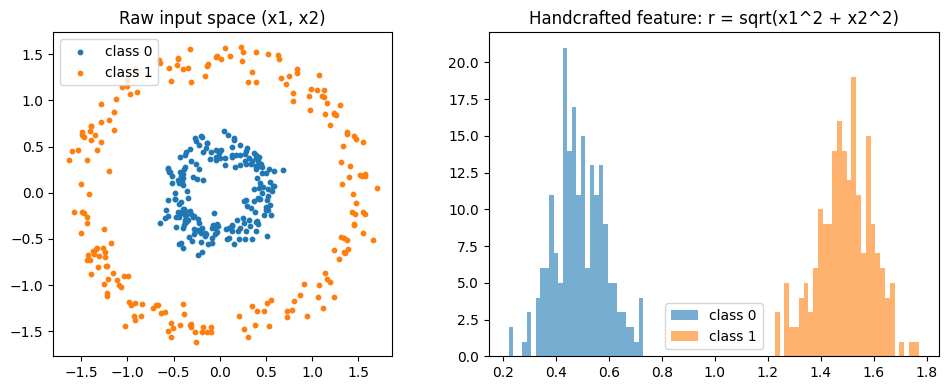

In [3]:
# Toy dataset: two concentric rings (a classic non-linearly-separable problem)
n = 200
theta = np.random.rand(n) * 2 * np.pi
r_inner = 0.5 + 0.1 * np.random.randn(n)
r_outer = 1.5 + 0.1 * np.random.randn(n)

X_inner = np.stack([r_inner * np.cos(theta), r_inner * np.sin(theta)], axis=1)
X_outer = np.stack([r_outer * np.cos(theta), r_outer * np.sin(theta)], axis=1)
X = np.vstack([X_inner, X_outer])
y = np.array([0] * n + [1] * n)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(X[y == 0, 0], X[y == 0, 1], label='class 0', s=10)
ax[0].scatter(X[y == 1, 0], X[y == 1, 1], label='class 1', s=10)
ax[0].set_title("Raw input space (x1, x2)")
ax[0].legend(); ax[0].set_aspect('equal')

# Handcrafted feature: radius
r = np.sqrt(X[:, 0] ** 2 + X[:, 1] ** 2)
ax[1].hist(r[y == 0], bins=30, alpha=0.6, label='class 0')
ax[1].hist(r[y == 1], bins=30, alpha=0.6, label='class 1')
ax[1].set_title("Handcrafted feature: r = sqrt(x1^2 + x2^2)")
ax[1].legend()
plt.tight_layout()
plt.show()

Observation: in the raw `(x1, x2)` space the two classes are **interleaved**, so a straight line cannot separate them. But once we apply the handcrafted feature `r = sqrt(x1^2 + x2^2)`, a simple threshold on `r` works perfectly.

The whole idea of end-to-end learning is: **we don't want to design `r` by hand** — we want the network to discover such a useful representation on its own.

### Part 2: The McCulloch-Pitts Neuron (1943)

The very first mathematical model of a neuron. It is extremely simple:

* inputs $x_i \in \{0, 1\}$ (binary)
* no weights — all inputs count equally
* an aggregation function (sum) and a **threshold** $\theta$
* output $y \in \{0, 1\}$:

$$ y = \begin{cases} 1 & \text{if } \sum_i x_i \geq \theta \\ 0 & \text{otherwise} \end{cases} $$

We can implement basic Boolean gates by picking the right threshold.

In [4]:
def mp_neuron(inputs, theta):
    """McCulloch-Pitts neuron: fires if sum of binary inputs >= theta."""
    return int(sum(inputs) >= theta)

# AND: fires only if BOTH inputs are 1  ->  theta = 2
# OR : fires if AT LEAST ONE input is 1 ->  theta = 1
inputs_2 = [(0, 0), (0, 1), (1, 0), (1, 1)]
print(f"{'x1':>3} {'x2':>3} | {'AND':>3} {'OR':>3}")
print("-" * 20)
for x1, x2 in inputs_2:
    print(f"{x1:>3} {x2:>3} | {mp_neuron([x1, x2], 2):>3} {mp_neuron([x1, x2], 1):>3}")

 x1  x2 | AND  OR
--------------------
  0   0 |   0   0
  0   1 |   0   1
  1   0 |   0   1
  1   1 |   1   1


#### Limitation: the XOR problem

XOR fires when **exactly one** input is 1. With a single McCulloch-Pitts neuron (just sum + threshold, equal weights) there is no threshold $\theta$ that reproduces the XOR truth table:

| x1 | x2 | XOR |
|----|----|-----|
| 0  | 0  | 0   |
| 0  | 1  | 1   |
| 1  | 0  | 1   |
| 1  | 1  | 0   |

Let's confirm that no single threshold works.

In [5]:
for theta in [1, 2]:
    out = [mp_neuron([x1, x2], theta) for x1, x2 in inputs_2]
    print(f"theta={theta}: outputs={out}")
print("target XOR     : [0, 1, 1, 0]  <-- no single theta reproduces this")

theta=1: outputs=[0, 1, 1, 1]
theta=2: outputs=[0, 0, 0, 1]
target XOR     : [0, 1, 1, 0]  <-- no single theta reproduces this


This is the famous **XOR problem** (Minsky, 1969). Other limitations of the McCulloch-Pitts neuron:

* only Boolean inputs/outputs,
* all inputs are treated equally (no weights),
* the threshold $\theta$ has to be **hand-coded** — there is no learning algorithm.

### Part 3: The Rosenblatt Perceptron (1958)

Frank Rosenblatt extended the McCulloch-Pitts neuron with two crucial ideas:

1. **weights** $w_i \in \mathbb{R}$ for every input (not just equal votes),
2. **real-valued inputs** $x_i \in \mathbb{R}$.

The neuron computes

$$ z = \sum_{i=1}^{d} w_i x_i + b = \mathbf{w}^\top \mathbf{x} + b $$

and applies a **step activation**:

$$ y = \varphi(z) = \begin{cases} 1 & \text{if } z \geq 0 \\ 0 & \text{otherwise} \end{cases} $$

The bias $b$ plays the role of the (negative) threshold. Rosenblatt also proposed a **learning algorithm** for finding the weights from labeled data — we will cover that in the next lecture.

For now we just implement the **forward pass** with hand-set weights.

In [6]:
def step(z):
    return (z >= 0).astype(int)

def perceptron_forward(X, w, b):
    """Forward pass of a Rosenblatt perceptron. X: (N, d), w: (d,), b: scalar."""
    z = X @ w + b
    return step(z)

# Hand-crafted weights for an AND gate on real inputs
X_bool = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
w_and = np.array([1.0, 1.0])
b_and = -1.5  # fires only when x1 + x2 >= 1.5, i.e. both are 1
print("AND :", perceptron_forward(X_bool, w_and, b_and))

# Hand-crafted weights for an OR gate
w_or = np.array([1.0, 1.0])
b_or = -0.5
print("OR  :", perceptron_forward(X_bool, w_or, b_or))

AND : [0 0 0 1]
OR  : [0 1 1 1]


#### Geometrically: a perceptron is a hyperplane

Setting $\mathbf{w}^\top \mathbf{x} + b = 0$ defines a **hyperplane** (a line in 2D). The perceptron outputs 1 on one side and 0 on the other. Let's visualize it for the AND gate.

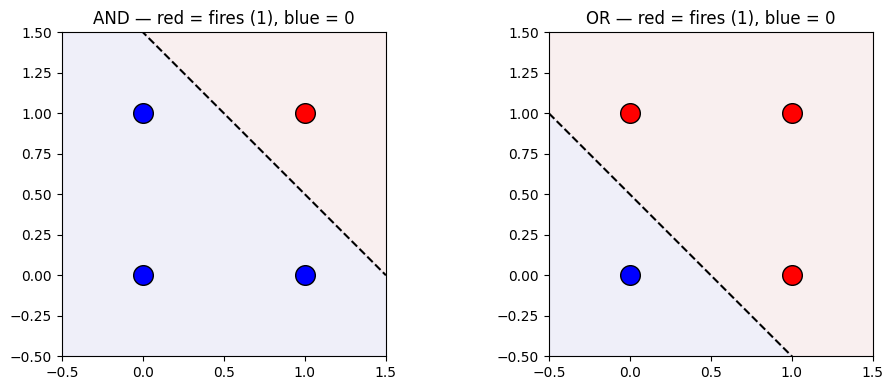

In [7]:
def plot_decision_boundary(w, b, ax, xlim=(-0.5, 1.5), ylim=(-0.5, 1.5)):
    xs = np.linspace(*xlim, 200)
    ys = np.linspace(*ylim, 200)
    XX, YY = np.meshgrid(xs, ys)
    grid = np.stack([XX.ravel(), YY.ravel()], axis=1)
    ZZ = perceptron_forward(grid, w, b).reshape(XX.shape)
    ax.contourf(XX, YY, ZZ, levels=[-0.5, 0.5, 1.5], alpha=0.3, colors=['#cce', '#ecc'])
    # the boundary w . x + b = 0 -> x2 = -(w1*x1 + b)/w2
    if abs(w[1]) > 1e-8:
        ax.plot(xs, -(w[0] * xs + b) / w[1], 'k--')
    ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_aspect('equal')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, w, b) in zip(axes, [("AND", w_and, b_and), ("OR", w_or, b_or)]):
    plot_decision_boundary(w, b, ax)
    out = perceptron_forward(X_bool, w, b)
    for (x1, x2), o in zip(X_bool, out):
        ax.scatter(x1, x2, s=200, c='red' if o else 'blue', edgecolors='black', zorder=3)
    ax.set_title(f"{name} — red = fires (1), blue = 0")
plt.tight_layout(); plt.show()

Key geometric insight: a single perceptron can only implement **linearly separable** functions — those whose positive and negative examples can be split by a straight line (or hyperplane in higher dimensions).

**XOR is not linearly separable** — and this is exactly why a single perceptron fails on it. You can try: there is no `(w1, w2, b)` that makes the perceptron output `[0, 1, 1, 0]` on the four corners.

> Remarks from the lecture:
> * linear regression = a single neuron with a **linear** activation function,
> * logistic regression = a single neuron with a **sigmoid** activation function.

### Part 4: Activation Functions

Why do we need an activation function? Two reasons:

1. **Non-linearity** — without it, stacking layers is useless: a composition of linear maps is still linear, so no matter how deep the network is it could only represent linear functions.
2. **Differentiability** — later, training via gradient descent needs the derivative of the activation. The original step function is not differentiable at 0, which is one reason modern networks use smooth alternatives.

Let's plot the most common activation functions.

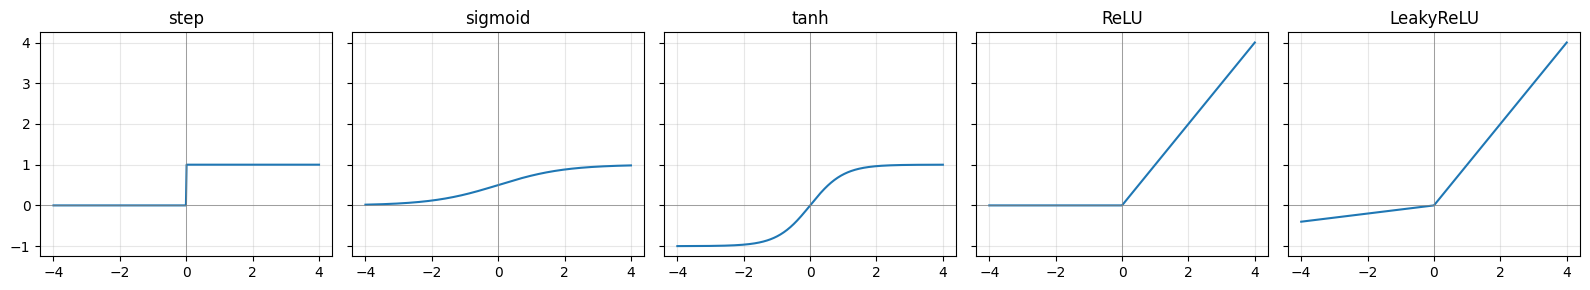

In [8]:
def step_fn(z):   return (z >= 0).astype(float)
def sigmoid(z):   return 1.0 / (1.0 + np.exp(-z))
def tanh(z):      return np.tanh(z)
def relu(z):      return np.maximum(0.0, z)
def leaky_relu(z, alpha=0.1): return np.where(z >= 0, z, alpha * z)

z = np.linspace(-4, 4, 400)

fig, axes = plt.subplots(1, 5, figsize=(16, 3), sharey=True)
for ax, (name, f) in zip(axes, [
    ("step", step_fn), ("sigmoid", sigmoid), ("tanh", tanh),
    ("ReLU", relu), ("LeakyReLU", leaky_relu),
]):
    ax.plot(z, f(z))
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.set_title(name); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Quick comparison:

| name       | range          | differentiable | notes |
|------------|---------------|----------------|-------|
| step       | {0, 1}        | no (at 0)      | original perceptron |
| sigmoid    | (0, 1)        | yes            | smooth, saturates → vanishing gradient |
| tanh       | (-1, 1)       | yes            | zero-centered version of sigmoid |
| ReLU       | [0, ∞)        | yes (a.e.)     | cheap, dominant in modern nets |
| LeakyReLU  | (-∞, ∞)       | yes (a.e.)     | avoids "dead" neurons |

### Part 5: Solving XOR with a Multi-Layer Perceptron

Since XOR is not linearly separable, no single perceptron can solve it. But we can write XOR as a combination of simpler gates:

$$ x_1 \oplus x_2 = (x_1 \text{ OR } x_2) \text{ AND } (x_1 \text{ NAND } x_2) $$

So with **two perceptrons in a hidden layer** (one computing OR, one computing NAND) and **one perceptron in the output layer** (computing AND of the two hidden outputs), XOR becomes solvable.

This is a tiny **Multi-Layer Perceptron (MLP)**: input layer (2) → hidden layer (2) → output layer (1).

In [9]:
# Hidden layer: 2 neurons, each is a perceptron
# neuron 1: OR    -> w=[1, 1], b=-0.5
# neuron 2: NAND  -> w=[-1,-1], b=1.5
W1 = np.array([[1.0, 1.0],     # weights of OR neuron
               [-1.0, -1.0]])   # weights of NAND neuron
b1 = np.array([-0.5, 1.5])

# Output layer: 1 neuron doing AND of the two hidden outputs
W2 = np.array([[1.0, 1.0]])    # shape (1, 2)
b2 = np.array([-1.5])

def mlp_xor_forward(X):
    h = step((X @ W1.T) + b1)      # hidden activations, shape (N, 2)
    y = step((h @ W2.T) + b2)      # output, shape (N, 1)
    return h, y.ravel()

h, y_hat = mlp_xor_forward(X_bool)
print("  x1 x2 | h1=OR  h2=NAND |  y=XOR  target")
print("-" * 45)
target = [0, 1, 1, 0]
for (x, hi, yi, t) in zip(X_bool, h, y_hat, target):
    print(f"   {x[0]}  {x[1]} |   {hi[0]}      {hi[1]}    |   {yi}       {t}")

  x1 x2 | h1=OR  h2=NAND |  y=XOR  target
---------------------------------------------
   0  0 |   0      1    |   0       0
   0  1 |   1      1    |   1       1
   1  0 |   1      1    |   1       1
   1  1 |   1      0    |   0       0


This MLP solves XOR exactly. The **hidden layer** has transformed the inputs into a new 2D space `(h1, h2)` in which the problem **is** linearly separable, and the output neuron separates the two classes with a single hyperplane.

This is the core idea of deep learning: **stacking non-linear layers lets the network re-represent the data in a space where the task becomes easy**.

> *Universal Approximation Theorem (1989):* an MLP with a single hidden layer and sigmoid activations can approximate any continuous function to arbitrary precision — as long as the hidden layer has enough neurons. So expressivity is not the problem. The challenges are: *how many neurons?* and *how do we find the weights?* (Next lecture: training with backpropagation.)

### Part 6: Vectorized Forward Pass

So far we treated each neuron separately. In practice we always use the **vectorized** formulation.

Notation from the lecture:

* $\mathbf{a}^{(\ell)} \in \mathbb{R}^{n_\ell}$: activation vector of layer $\ell$
* $\mathbf{b}^{(\ell)} \in \mathbb{R}^{n_\ell}$: bias vector of layer $\ell$
* $W^{(\ell)} \in \mathbb{R}^{n_\ell \times n_{\ell-1}}$: weight matrix between layer $\ell-1$ and layer $\ell$
* $\varphi$: activation function, applied element-wise

Forward pass of layer $\ell$:

$$ \mathbf{z}^{(\ell)} = W^{(\ell)} \mathbf{a}^{(\ell-1)} + \mathbf{b}^{(\ell)} \qquad \mathbf{a}^{(\ell)} = \varphi\bigl(\mathbf{z}^{(\ell)}\bigr) $$

with $\mathbf{a}^{(0)} = \mathbf{x}$ (the input). Let's implement this for a 2-hidden-layer MLP with `tanh` activations and **random** weights (we are not training yet, we just want to see the forward pass work).

In [10]:
def forward(x, weights, biases, activation=np.tanh):
    """Generic forward pass. weights: list of W matrices, biases: list of b vectors."""
    a = x
    activations = [a]
    for W, b in zip(weights, biases):
        z = W @ a + b
        a = activation(z)
        activations.append(a)
    return a, activations

# Architecture: 3 -> 4 -> 4 -> 2  (input dim 3, two hidden layers of 4, output 2)
layer_sizes = [3, 4, 4, 2]
weights, biases = [], []
for n_in, n_out in zip(layer_sizes[:-1], layer_sizes[1:]):
    weights.append(np.random.randn(n_out, n_in) * 0.5)
    biases.append(np.random.randn(n_out) * 0.1)

x = np.array([1.0, -0.5, 2.0])
y, acts = forward(x, weights, biases)

for i, a in enumerate(acts):
    print(f"a^({i}) (shape {a.shape}):  {np.round(a, 3)}")
print(f"\nFinal output y = a^({len(acts) - 1}):  {np.round(y, 3)}")

a^(0) (shape (3,)):  [ 1.  -0.5  2. ]
a^(1) (shape (4,)):  [-0.987 -0.704 -0.14   0.417]
a^(2) (shape (4,)):  [-0.418  0.624  0.904  0.531]
a^(3) (shape (2,)):  [-0.186 -0.376]

Final output y = a^(3):  [-0.186 -0.376]


**Neural networks are nested functions.** Writing the whole network as one expression:

$$ \mathbf{y} = \varphi\!\bigl( W^{(3)} \,\varphi\!\bigl( W^{(2)} \,\varphi\!\bigl( W^{(1)} \mathbf{x} + \mathbf{b}^{(1)} \bigr) + \mathbf{b}^{(2)} \bigr) + \mathbf{b}^{(3)} \bigr) $$

The signal flows *from the inside out* — that's the "forward pass". And because it is just function composition, we can compute the derivative of the output with respect to every parameter using the chain rule — that will be **backpropagation** in the next lecture.

### Part 7: Classification Setup — one-hot encoding and softmax

How do we actually use such a network for **classification**?

* **Input.** A $d$-dimensional feature vector $\mathbf{x} \in \mathbb{R}^d$.
* **Output.** A $c$-dimensional vector $\mathbf{y} \in \mathbb{R}^c$, where $c$ is the number of classes.
* **Ground truth.**
  * *Binary classification* ($c = 1$): $y \in \{0, 1\}$ directly.
  * *Multi-class* ($c$ classes): **one-hot encoding**. Class $k$ is encoded as a vector with 1 at position $k$ and 0 elsewhere.

In [11]:
def one_hot(labels, num_classes):
    """Convert a vector of class indices into one-hot rows."""
    out = np.zeros((len(labels), num_classes))
    out[np.arange(len(labels)), labels] = 1
    return out

labels = np.array([0, 2, 1, 9, 4])  # e.g. digit labels from MNIST
print("labels :", labels)
print("one-hot:")
print(one_hot(labels, num_classes=10))

labels : [0 2 1 9 4]
one-hot:
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


#### Softmax

The raw output of the network (called **logits**) can be any real number. To turn them into class probabilities we apply the **softmax** function:

$$ \text{softmax}(\mathbf{z})_i = \frac{e^{z_i}}{\sum_{j=1}^{c} e^{z_j}} $$

Properties: every component is in $(0, 1)$ and they sum to 1 — so we can read the output as a probability distribution over the $c$ classes. For numerical stability it is common to use **LogSoftmax** instead.

In [12]:
def softmax(z):
    z = z - np.max(z)  # numerical stability: subtract the max before exp
    e = np.exp(z)
    return e / e.sum()

logits = np.array([2.0, 1.0, 0.1, -1.0, 3.5])
probs = softmax(logits)
print("logits:       ", np.round(logits, 2))
print("probabilities:", np.round(probs, 3))
print("sum =", probs.sum(), "   predicted class =", int(np.argmax(probs)))

logits:        [ 2.   1.   0.1 -1.   3.5]
probabilities: [0.165 0.061 0.025 0.008 0.741]
sum = 1.0    predicted class = 4


### Part 8: Introduction to PyTorch

Everything we did so far was NumPy. In practice, we use a **deep learning framework** that handles:

* **tensor** operations (like NumPy, but with GPU support),
* **automatic differentiation** — it tracks operations on tensors and computes gradients for us (so we don't have to derive backprop by hand),
* ready-made neural-network **building blocks** (`nn.Linear`, activations, losses, optimizers, ...).

The most widely used framework is [PyTorch](https://pytorch.org/). Let's get a first feel for it.

In [ ]:
import torch
import torch.nn as nn

print("PyTorch version:", torch.__version__)

#### 8.1 Tensors

A `torch.Tensor` is the PyTorch equivalent of a NumPy array. Most NumPy operations have a direct counterpart.

In [14]:
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([10.0, 20.0, 30.0])

print("a       =", a)
print("a + b   =", a + b)
print("a.dot(b)=", a.dot(b))
print("shape   =", a.shape, "   dtype =", a.dtype)

# Conversion from / to NumPy
x_np = np.array([[1.0, 2.0], [3.0, 4.0]])
x_t  = torch.from_numpy(x_np)
print("\nfrom NumPy:\n", x_t)
print("back to NumPy:\n", x_t.numpy())

a       = tensor([1., 2., 3.])
a + b   = tensor([11., 22., 33.])
a.dot(b)= tensor(140.)
shape   = torch.Size([3])    dtype = torch.float32

from NumPy:
 tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)
back to NumPy:
 [[1. 2.]
 [3. 4.]]


#### 8.2 Autograd — automatic differentiation

The feature that makes PyTorch really useful (and that we will fully exploit in the next lecture for training) is **autograd**: if you set `requires_grad=True`, PyTorch tracks the operations you do with a tensor and can compute derivatives automatically.

In [15]:
# Example: f(u) = u^2 + 3u, compute df/du at u = 2
u = torch.tensor(2.0, requires_grad=True)
f = u ** 2 + 3 * u
f.backward()                 # triggers automatic differentiation
print("f(2)   =", f.item())
print("df/du  =", u.grad.item(), "  (expected: 2*2 + 3 = 7)")

f(2)   = 10.0
df/du  = 7.0   (expected: 2*2 + 3 = 7)


#### 8.3 Building a neural network with `torch.nn`

Instead of managing weight matrices and bias vectors ourselves, we use `nn.Linear(in_features, out_features)`. It contains the parameters $W$ and $\mathbf{b}$. We can stack several layers using `nn.Sequential`.

Let's build the same 3 → 4 → 4 → 2 MLP as before.

In [16]:
model = nn.Sequential(
    nn.Linear(3, 4),
    nn.Tanh(),
    nn.Linear(4, 4),
    nn.Tanh(),
    nn.Linear(4, 2),
    nn.Tanh(),
)
print(model)

# Count parameters
n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {n_params}")

# Forward pass on our earlier input
x_t = torch.tensor([1.0, -0.5, 2.0])
y_t = model(x_t)
print("\nInput :", x_t)
print("Output:", y_t.detach())

Sequential(
  (0): Linear(in_features=3, out_features=4, bias=True)
  (1): Tanh()
  (2): Linear(in_features=4, out_features=4, bias=True)
  (3): Tanh()
  (4): Linear(in_features=4, out_features=2, bias=True)
  (5): Tanh()
)

Total parameters: 46

Input : tensor([ 1.0000, -0.5000,  2.0000])
Output: tensor([-0.1773, -0.5208])


Note: because PyTorch initialises weights **randomly**, the output differs from our NumPy version — we haven't aligned the weights between the two models. Let's do that explicitly, just to prove the two computations agree.

In [17]:
# Copy our NumPy weights/biases into the PyTorch model
with torch.no_grad():
    for layer, (W, b) in zip(
        [m for m in model if isinstance(m, nn.Linear)],
        zip(weights, biases),
    ):
        layer.weight.copy_(torch.from_numpy(W).float())
        layer.bias.copy_(torch.from_numpy(b).float())

y_numpy, _ = forward(x, weights, biases)           # NumPy version from Part 6
y_torch   = model(torch.from_numpy(x).float()).detach().numpy()

print("NumPy output  :", np.round(y_numpy, 4))
print("PyTorch output:", np.round(y_torch, 4))

NumPy output  : [-0.1858 -0.3762]
PyTorch output: [-0.1858 -0.3762]


Same computation — PyTorch is simply doing matrix multiplications and tanh under the hood, but with autograd and GPU support on top.

#### 8.4 Re-implementing the XOR MLP in PyTorch

Finally, let's re-implement our hand-crafted XOR solver from Part 5 using PyTorch modules. We'll set the weights by hand (since training comes next lecture) and use the step function as activation — note that we use `nn.Linear` for the affine part and apply the activation manually.

In [18]:
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2, 2)
        self.out    = nn.Linear(2, 1)

    def forward(self, x):
        h = (self.hidden(x) >= 0).float()   # step activation, hidden layer
        y = (self.out(h) >= 0).float()      # step activation, output layer
        return y

net = XORNet()

# Set the hand-crafted weights from Part 5
with torch.no_grad():
    net.hidden.weight.copy_(torch.tensor([[1.0, 1.0], [-1.0, -1.0]]))  # OR, NAND
    net.hidden.bias.copy_(torch.tensor([-0.5, 1.5]))
    net.out.weight.copy_(torch.tensor([[1.0, 1.0]]))                    # AND
    net.out.bias.copy_(torch.tensor([-1.5]))

X_t = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
print("input  ->  XOR prediction")
for x, y in zip(X_t, net(X_t)):
    print(f"  {x.tolist()}  ->  {int(y.item())}")

input  ->  XOR prediction
  [0.0, 0.0]  ->  0
  [0.0, 1.0]  ->  1
  [1.0, 0.0]  ->  1
  [1.0, 1.0]  ->  0


### Summary

In this lab we covered:

* **End-to-end learning** learns features and classifier jointly, in contrast to traditional pipelines with handcrafted features.
* The **McCulloch-Pitts neuron** is the simplest artificial neuron but has severe limitations (boolean only, no weights, no learning, XOR fails).
* The **Rosenblatt perceptron** introduces weights and real-valued inputs, but still implements only a linear decision boundary.
* **Activation functions** (sigmoid, tanh, ReLU, ...) provide the non-linearity we need to stack layers meaningfully.
* An **MLP** can solve non-linearly-separable problems like XOR by re-representing the input in a space where it becomes linearly separable.
* A network's forward pass is **nothing but a nested function** `y = φ(W^(L) ... φ(W^(1) x + b^(1)) ... + b^(L))`, easily written vectorized with matrix multiplications.
* For classification we combine this with **one-hot encoding** on the target side and **softmax** on the output side.
* **PyTorch** gives us tensors, autograd, and ready-made building blocks (`nn.Linear`, `nn.Sequential`, `nn.Module`) that we'll rely on from now on.

**Next lecture:** how to actually **learn** the weights from data — loss functions, gradient descent, and backpropagation.